# Módulo 2: Estadística y Visualización de Datos
- **Sesión:** 04 — Gráficos avanzados (circular, cajas, dispersión, seaborn y APIs)
- **Cuaderno del alumno**
- **Fecha:** 29/11/2025
- **Actualización:** 15/08/2026

## Objetivos de la sesión
1. Construir gráficos circulares con `plt.pie` y sus opciones (`autopct`, `explode`, `colors`, `shadow`, `startangle`).
2. Construir e **interpretar** diagramas de cajas (boxplot), conectándolos con los cuartiles y el $IQR$ de la sesión 02.
3. Detectar valores atípicos programáticamente con la regla del rango intercuartílico.
4. Construir diagramas de dispersión desde listas, DataFrames y archivos CSV.
5. Conocer **seaborn** como capa de alto nivel sobre matplotlib.
6. Consumir datos en línea desde **APIs** (BCRP y FMI) y graficarlos.

> 📝 Los ejercicios están **propuestos** a lo largo del notebook, con una celda vacía para su solución.

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Gráfico circular a partir de una lista

### Teoría

Un **gráfico circular** muestra las **proporciones** de las partes de un todo: cada categoría $i$ ocupa un ángulo proporcional a su participación

$$\theta_i = 360° \cdot \frac{x_i}{\sum_{j=1}^{k} x_j} \qquad\qquad p_i = \frac{x_i}{\sum_{j=1}^{k} x_j} \cdot 100\%$$

Parámetros principales de `plt.pie(valores, ...)`:

| Parámetro | Descripción |
|---|---|
| `labels` | Nombre de cada porción |
| `colors` | Lista de colores por porción |
| `startangle` | Ángulo inicial en grados (90 = empieza arriba) |
| `explode` | Tupla que separa porciones del centro para resaltarlas |
| `shadow` | Sombra bajo el gráfico |
| `autopct` | Formato del porcentaje sobre cada porción (`"%1.1f%%"`) |
| `textprops` | Diccionario de propiedades del texto (tamaño, peso) |

⚠️ **Cuándo NO usar un gráfico circular:** con muchas categorías (más de ~5-6) o con valores similares entre sí, el ojo compara mal ángulos y áreas — en esos casos un gráfico de **barras** comunica mejor. El circular funciona bien cuando el mensaje es *"qué parte del total representa cada uno"* con pocas categorías diferenciadas.

### Laboratorio

### IDC Corporate: Smartphone Market Insights — 1Q-2026 Shipment Volumes

Source: https://www.idc.com/promo/smartphone-market-share/market-share/

<img src="imagenes/IDC_Q1_2026_MarketShare_Smartphone.png" width="800"/>

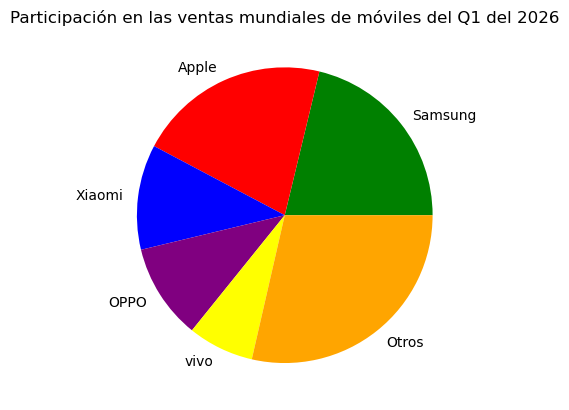

In [128]:
# Cantidad de móviles vendidos en Q1-2026 (millones de unidades)
etiquetas = ["Samsung", "Apple", "Xiaomi", "OPPO", "vivo", "Otros"]
valores = [62.4, 61.8, 33.8, 30.7, 21.2, 84.0]
colores = ["green", "red", "blue", "purple", "yellow", "orange"]

plt.title("Participación en las ventas mundiales de móviles del Q1 del 2026")
plt.pie(valores, labels=etiquetas, colors=colores)
plt.savefig("output/pie-01")
plt.show()

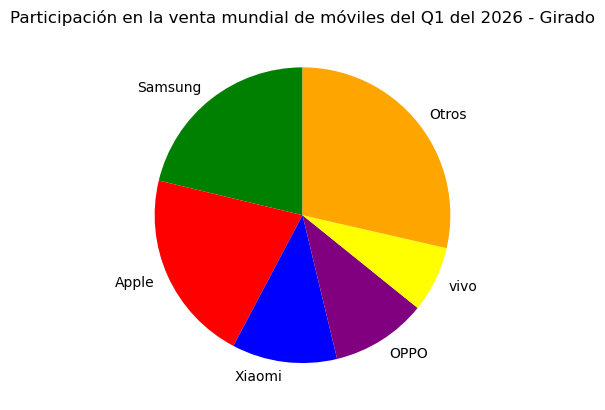

In [129]:
plt.title("Participación en la venta mundial de móviles del Q1 del 2026 - Girado")
plt.pie(valores, labels=etiquetas, colors=colores, startangle=90)   # gira 90 grados
plt.savefig("output/pie-02")
plt.show()

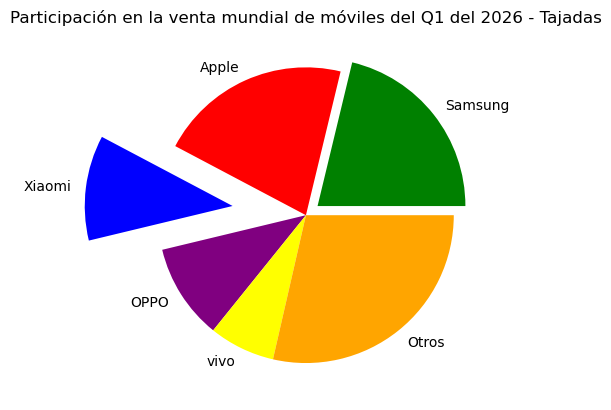

In [130]:
explode = [0.1, 0, 0.5, 0, 0, 0]

plt.title("Participación en la venta mundial de móviles del Q1 del 2026 - Tajadas")
plt.pie(valores, labels=etiquetas, colors=colores, explode=explode)  # tajadas separadas
plt.savefig("output/pie-03")
plt.show()

Con `fontdict` personalizamos el título y con `shadow` agregamos sombra:

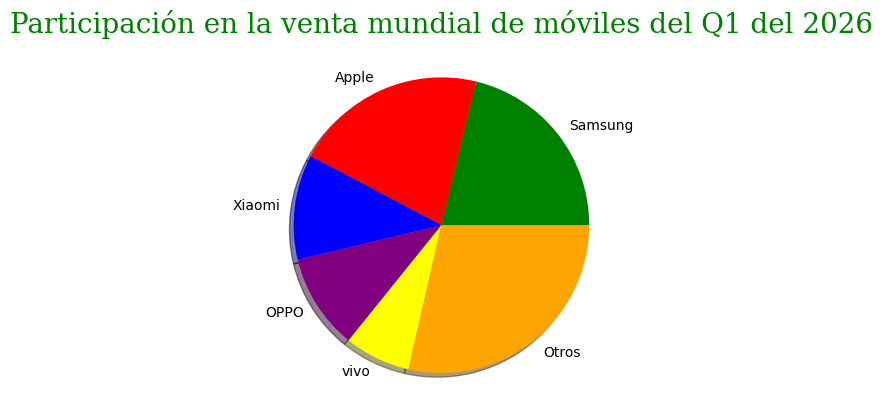

In [131]:
font = {"family": "serif",
        "color": "green",
        "weight": "normal",
        "size": 20}

plt.title("Participación en la venta mundial de móviles del Q1 del 2026", fontdict=font)
plt.pie(valores, labels=etiquetas, colors=colores, shadow=True)
plt.savefig("output/pie-04")
plt.show()

Finalmente, `autopct` muestra el porcentaje de cada porción — casi siempre conviene incluirlo:

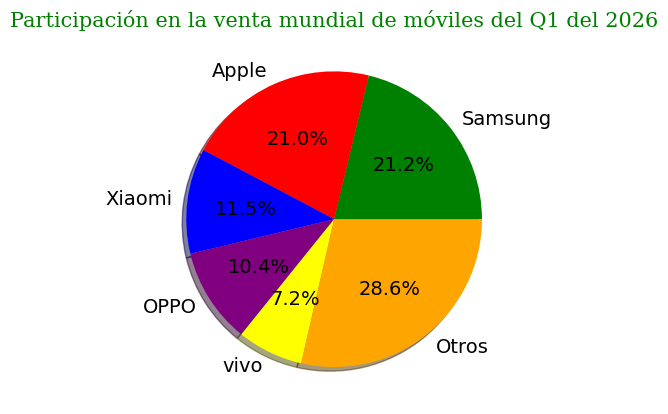

In [132]:
font["size"] = 15

plt.title("Participación en la venta mundial de móviles del Q1 del 2026", fontdict=font)
plt.pie(valores, labels=etiquetas, colors=colores, shadow=True,
        autopct="%1.1f%%", textprops={"fontsize": 14})
plt.savefig("output/pie-05")
plt.show()

Otro ejemplo con datos del SIPRI — gasto militar 2025 (en **miles de millones** de US$):

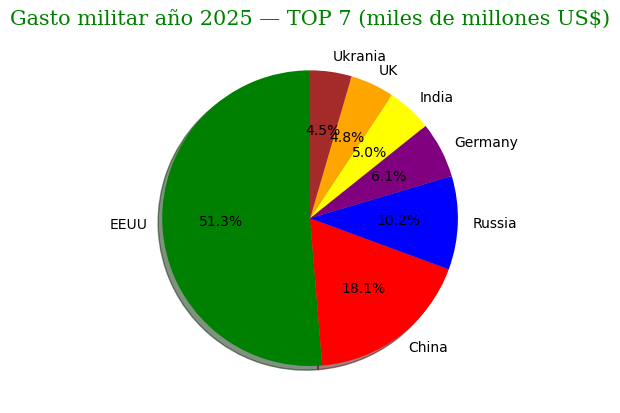

In [133]:
# Gasto militar 2025 — Top 7 (miles de millones de US$)
etiquetas = ["EEUU", "China", "Russia", "Germany", "India", "UK", "Ukrania"]
valores = [954, 336, 190, 114, 92.1, 89.0, 84.1]
colores = ["green", "red", "blue", "purple", "yellow", "orange", "brown"]

plt.title("Gasto militar año 2025 — TOP 7 (miles de millones US$)", fontdict=font)
plt.pie(valores, labels=etiquetas, colors=colores, shadow=True,
        autopct="%1.1f%%", startangle=90, textprops={"fontsize": 10})
plt.savefig("output/pie-06")
plt.show()

### 📝 Ejercicio 1 — Gráfico circular del PBI

Hacer un gráfico circular con el PBI del año 2026 de los países: Perú, Chile, Argentina, Colombia, Brasil y México, a partir del archivo `WEO_Data_Latinoamerica_2026.csv`. Muestre los porcentajes con `autopct`.

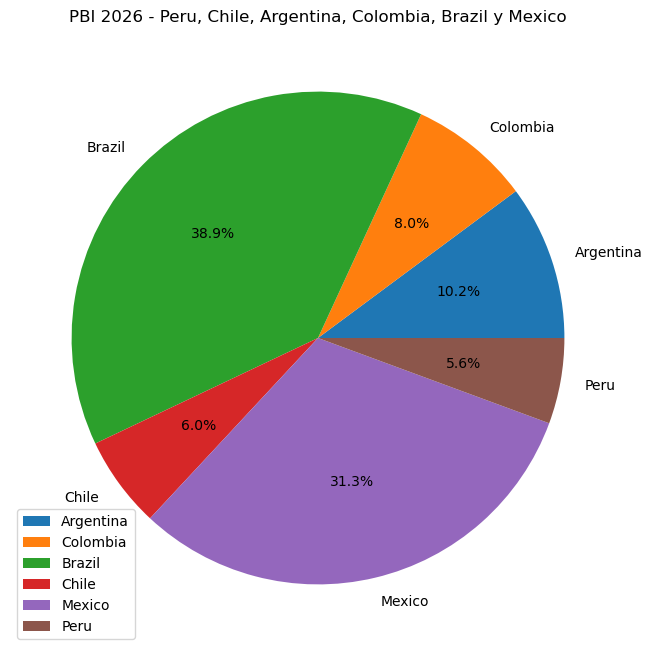

In [134]:
# Escriba su solución aquí


import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("dataset/fmi/WEO_Data_Latinoamerica_2026.csv")


paises = ["Peru", "Chile", "Argentina", "Colombia", "Brazil", "Mexico"]


df_paises = df[df["COUNTRY"].isin(paises)]


plt.figure(figsize=(8, 8))


plt.pie(
    df_paises["2026"],
    labels=df_paises["COUNTRY"],
    autopct="%1.1f%%"
)


plt.title("PBI 2026 - Peru, Chile, Argentina, Colombia, Brazil y Mexico")
plt.legend()
plt.show()

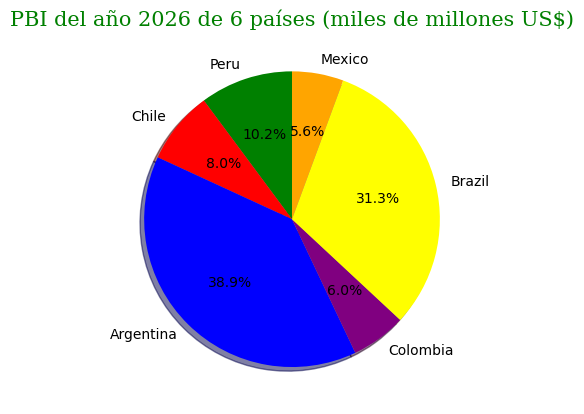

In [135]:
df = pd.read_csv("dataset/fmi/WEO_Data_Latinoamerica_2026.csv")

etiquetas = ["Peru", "Chile", "Argentina", "Colombia", "Brazil", "Mexico"]  
colores = ["green", "red", "blue", "purple", "yellow", "orange"]  
df_paises = df[df["COUNTRY"].isin(etiquetas)]  
plt.title("PBI del año 2026 de 6 países (miles de millones US$)", fontdict=font)  
plt.pie(df_paises["2026"], labels=etiquetas, colors=colores, shadow=True,  
    autopct="%1.1f%%", startangle=90, textprops={"fontsize": 10})  
plt.savefig("output/pie-06")  
plt.show()

### 📝 Ejercicio 2 — Gráfico circular del gasto militar

Hacer un gráfico circular con los gastos militares del año 2025 de los 7 países top, resaltando con `explode` al país de mayor gasto.

Fuente: https://www.sipri.org/visualizations/2026/sipri-map-world-military-expenditure-2025

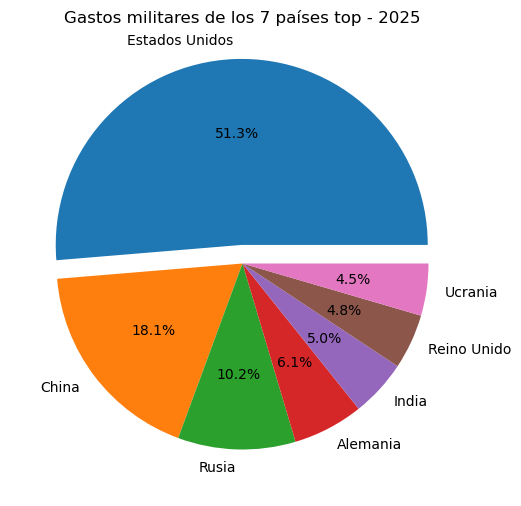

In [136]:
# Escriba su solución aquí
import matplotlib.pyplot as plt

paises = ["Estados Unidos", "China", "Rusia", "Alemania", "India", "Reino Unido", "Ucrania"]

gastos = [954, 336, 190, 114, 92.1, 89.0, 84.1]

explode = [0.1, 0, 0, 0, 0, 0, 0]

plt.figure(figsize=(6, 8))

plt.pie(gastos, labels=paises, autopct="%1.1f%%", explode=explode)

plt.title("Gastos militares de los 7 países top - 2025")
plt.show()

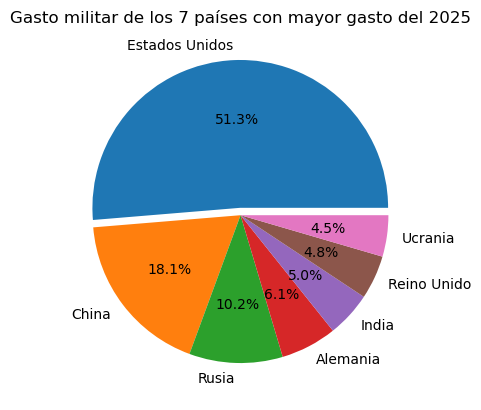

In [137]:
import pandas as pd
import matplotlib.pyplot as plt


paises = [
    "Estados Unidos",
    "China",
    "Rusia",
    "Alemania",
    "India",
    "Reino Unido",
    "Ucrania"
]


gastos = [
    954,
    336,
    190,
    114,
    92.1,
    89.0,
    84.1
]


explode = [0.05, 0, 0, 0, 0, 0, 0]


plt.pie(
    gastos,
    labels=paises,
    autopct="%1.1f%%",
    explode=explode
)


plt.title("Gasto militar de los 7 países con mayor gasto del 2025")


plt.show()

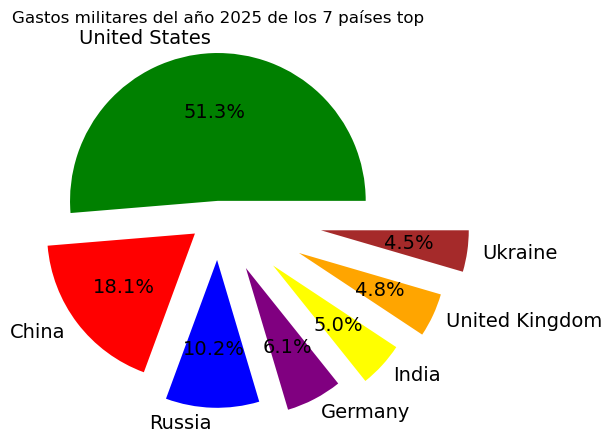

In [138]:
etiquetas = ["United States", "China", "Russia", "Germany", "India", "United Kingdom", "Ukraine"]
valores = [954, 336, 190, 114, 92.1, 89, 84.1]
colores = ["green", "red", "blue", "purple", "yellow", "orange", "brown"]
explode = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
plt.title("Gastos militares del año 2025 de los 7 países top")
plt.pie(valores, labels=etiquetas, colors=colores, 
    autopct="%1.1f%%", explode=explode, textprops={"fontsize": 14})
plt.show()

## 2. Gráfico de cajas (Boxplot)

### Teoría

El **boxplot** resume la distribución de una variable con los cuartiles que calculamos en la sesión 02:

- La **caja** va de $Q_1$ a $Q_3$: contiene el 50% central de los datos, es decir, el rango intercuartílico $IQR = Q_3 - Q_1$.
- La línea dentro de la caja es la **mediana** ($Q_2$).
- Los **bigotes** se extienden hasta el último dato dentro de los límites

$$[\,Q_1 - 1.5 \cdot IQR,\;\; Q_3 + 1.5 \cdot IQR\,]$$

- Los puntos dibujados fuera de los bigotes son **valores atípicos** (*outliers*) — el mismo criterio del ejercicio de outliers de la sesión 02.

Es el gráfico ideal para **comparar distribuciones entre grupos** lado a lado.

### Laboratorio: boxplot desde una lista

Descomente las otras listas para experimentar cómo cambia la caja:

In [ ]:
notas_matematica = [10,15,20,15,5,5,5,10,19,19,19]   # caja grande: notas dispersas
# notas_matematica = [10,15,20,15,5,5,5,10,9,9,9]      # reduciendo el rango intercuartílico
# notas_matematica = [10,12,18,20,5,5,5,10,9,9,9]      # con outliers superiores
# notas_matematica = [11,12,18,20,11,10,11,10,12,1,2]  # con outliers superiores e inferiores

# print(notas_matematica)

# Calculo de los Quartiles
q1, q2, q3 = np.percentile(notas_matematica, [25, 50, 75])

print(f"Q1 (percentil 25): {q1:.2f}")
print(f"Q2 (mediana)     : {q2:.2f}")
print(f"Q3 (percentil 75): {q3:.2f}")


Q1 (percentil 25): 7.50
Q2 (mediana)     : 15.00
Q3 (percentil 75): 19.00


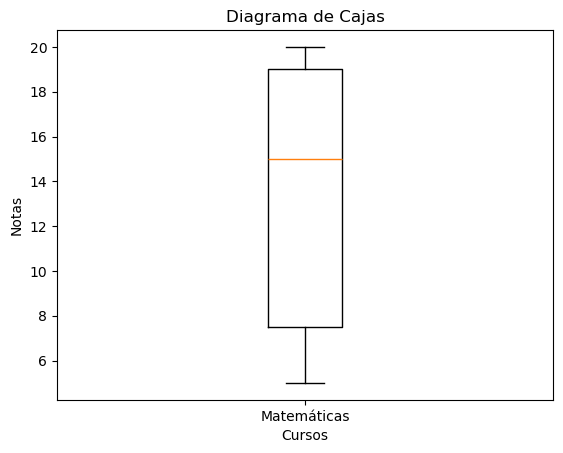

In [140]:
# Gráfico
plt.boxplot(notas_matematica, tick_labels=["Matemáticas"])
plt.title("Diagrama de Cajas")
plt.ylabel("Notas")
plt.xlabel("Cursos")
plt.savefig("output/boxplot-01")
plt.show()

**Interpretación del gráfico:**

- Mediana = 15: la mitad del grupo obtuvo una nota de 15 o más.
- $Q_1 = 7.5$, $Q_3 = 19$: el 50% central de las notas está entre estos dos valores ($IQR = 11.5$).
- Valor mínimo = 5, valor máximo = 20.
- No hay datos atípicos: los límites de los bigotes ($7.5 - 1.5 \cdot 11.5 = -9.75$ y $19 + 1.5 \cdot 11.5 = 36.25$) quedan fuera del rango de los datos.

**Conclusión:** las notas son muy dispersas y heterogéneas porque la caja es grande — hay mucha variabilidad entre los estudiantes. Aunque la mediana es 15, hay alumnos con notas muy bajas y muy altas: coexiste un grupo con conocimientos sólidos en matemáticas y otro casi igual de numeroso con conocimientos deficientes.

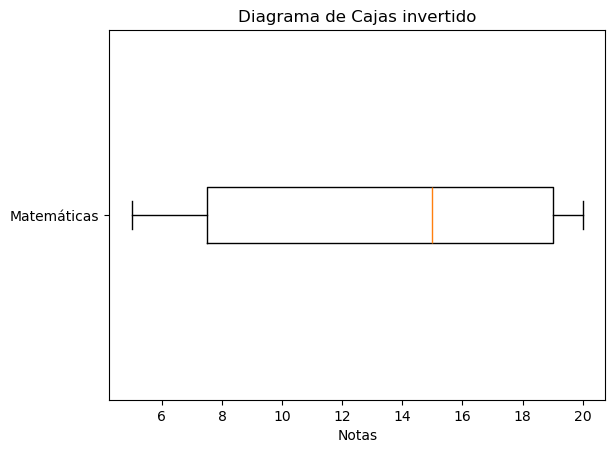

In [141]:
# Diagrama de caja horizontal
# Nota: en matplotlib >= 3.10 se recomienda orientation="horizontal" en lugar de vert=False
plt.boxplot(notas_matematica,
            tick_labels=["Matemáticas"],
            vert=False)
plt.title("Diagrama de Cajas invertido")
plt.xlabel("Notas")
plt.savefig("output/boxplot-02")
plt.show()

### Boxplot con pandas

In [142]:
diccionario = {"Matemática": [10,15,20,15,5,5,5,10,19,19,19]}
df = pd.DataFrame(diccionario)
df.head()

,Matemática
0,10
1,15
2,20
3,15
4,5


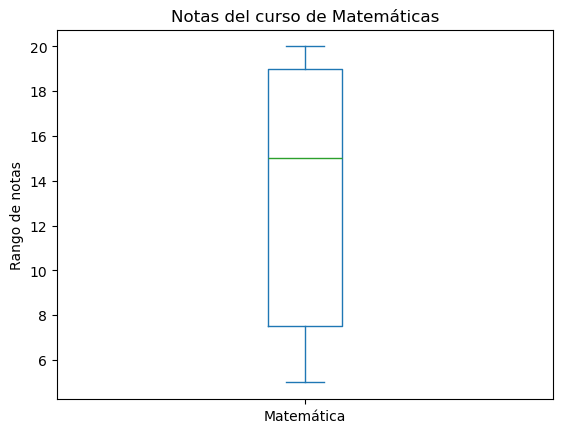

In [143]:
df.plot(kind="box")
plt.title("Notas del curso de Matemáticas")
plt.ylabel("Rango de notas")
plt.savefig("output/boxplot-03")
plt.show()

Con varias columnas, pandas dibuja una caja por curso — ideal para comparar:

In [144]:
diccionario = {"Matemática": [10,15,20,15,5,5,5,10,19,19,19],
               "Lenguaje":   [3,5,7,6,7,8,5,7,10,8,19],
               "Historia":   [19,18,17,12,17,18,15,3,10,18,19]}
df_subjects = pd.DataFrame(diccionario)
df_subjects.head()

,Matemática,Lenguaje,Historia
0,10,3,19
1,15,5,18
2,20,7,17
3,15,6,12
4,5,7,17


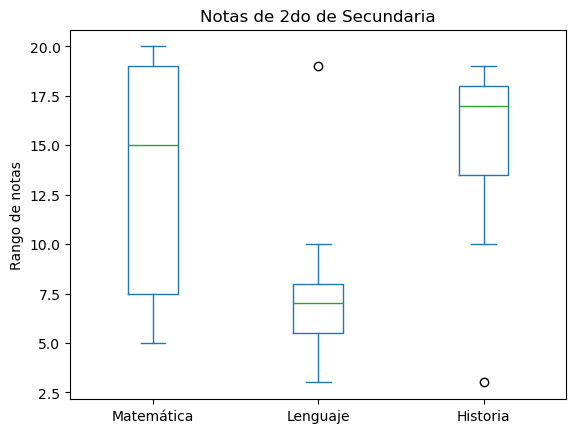

In [145]:
df_subjects.plot(kind="box")
plt.title("Notas de 2do de Secundaria")
plt.ylabel("Rango de notas")
plt.savefig("output/boxplot-04")
plt.show()

### 📝 Ejercicio 3 — Interpretación de boxplots

Observando el boxplot de los tres cursos, **interprete** las distribuciones de **Lenguaje** e **Historia**: mediana, dispersión, proporción aproximada de aprobados/desaprobados y valores atípicos. Escriba su interpretación en esta celda.

*✏️ Escriba aquí su interpretación...*

**Interpretacion de las notas de Lenguaje** : La nota media es de 7 puntos, y la mayor parte de los estudiantes tienen entre 5 y 8 puntos, lo cual indica que el nivel de lenguaje es critico, solo se tiene un alumn@ destacado que tiene una nota de 19. 

**Interpretacion de las notas de Historia**: 
Mediana = 17 Dispersión = 18-13 = 5
La nota media es 17 puntos y la mayor parte de estudiantes tienen entre 13 y 18 puntos, lo cual indica que el nivel es bastante bueno, sólo se tiene un alumno con nota muy baja de 3 puntos.

**OTRA Interpretacion de las notas de Lenguaje**
Lenguaje: Las notas están principalmente concentradas entre 5 y 10, por lo que existe cierta homogeneidad en la mayoría de los estudiantes. La caja es relativamente pequeña, indicando que el 50% central de las notas presenta poca dispersión. Sin embargo, la nota 19 se encuentra muy alejada del resto y aparece como un posible valor atípico.

**OTRA Interpretacion de las notas de Historia**: 
Las notas están principalmente concentradas entre 12 y 19, mostrando también cierta homogeneidad en la mayoría de los estudiantes. La caja es relativamente pequeña, indicando que el 50% central de las notas presenta poca dispersión. Sin embargo, la nota 3 se encuentra muy alejada del resto y aparece como un posible valor atípico.

### Identificando $Q_1$, $Q_2$, $Q_3$ y los outliers

`describe()` nos da los cuartiles de cada columna; con ellos implementamos la regla del $IQR$ en una función reutilizable:

In [ ]:
# Calculo de la mediana
df_subjects["Matemática"].quantile(0.50)

np.float64(15.0)

In [180]:
df_subjects.describe()

,Matemática,Lenguaje,Historia
count,11.000000,11.000000,11.000000
mean,12.909091,7.727273,15.090909
std,6.122982,4.173510,4.948829
min,5.000000,3.000000,3.000000
25%,7.500000,5.500000,13.500000
50%,15.000000,7.000000,17.000000
75%,19.000000,8.000000,18.000000
max,20.000000,19.000000,19.000000


In [172]:
def get_outliers(df, colname):
    """
    Obtiene los outliers de una columna de un DataFrame
    utilizando el método del rango intercuartílico (IQR).
    """
    Q1 = df[colname].quantile(0.25)
    Q3 = df[colname].quantile(0.75)
    IQR = Q3 - Q1
    upper_threshold = Q3 + 1.5 * IQR
    lower_threshold = Q1 - 1.5 * IQR
    outliers = df.loc[(df[colname] < lower_threshold) | (df[colname] > upper_threshold), colname]
    return outliers

In [183]:
for curso in ["Matemática", "Lenguaje", "Historia"]:
    print(f"Outliers de {curso}:")
    outliers = get_outliers(df_subjects, curso)
    if outliers.empty:
        print("  (ninguno)")
    for idx, value in outliers.items():
        print(f"  posición {idx} --> {value}")
    print("-" * 46)

Outliers de Matemática:
  (ninguno)
----------------------------------------------
Outliers de Lenguaje:
  posición 10 --> 19
----------------------------------------------
Outliers de Historia:
  posición 7 --> 3
----------------------------------------------


### Diagrama de cajas a partir de un archivo CSV

Cada caja resume la **distribución del PBI 2020-2029 de un país**: la posición de la caja indica el nivel del PBI y su altura, cuánto varió en la década.

In [185]:
filename = "dataset/fmi/WEO_Data_Latinoamerica_2026.csv"
df = pd.read_csv(filename)
df.set_index("COUNTRY", inplace=True)

list_country = ["Peru", "Chile", "Argentina", "Colombia", "Brazil", "Mexico"]
range_year = [str(x) for x in range(2020, 2030)]

df_countries = df.loc[list_country, range_year]
df_countries = df_countries.T
df_countries.head()

COUNTRY,Peru,Chile,Argentina,Colombia,Brazil,Mexico
2020,209.057,254.060,385.218,270.348,1476.092,1121.065
2021,228.704,315.411,486.040,318.525,1670.650,1316.569
2022,248.179,301.270,633.520,345.632,1951.849,1466.935
2023,272.755,335.627,648.895,366.901,2191.137,1794.410
2024,295.220,330.210,637.234,420.504,2185.822,1830.489


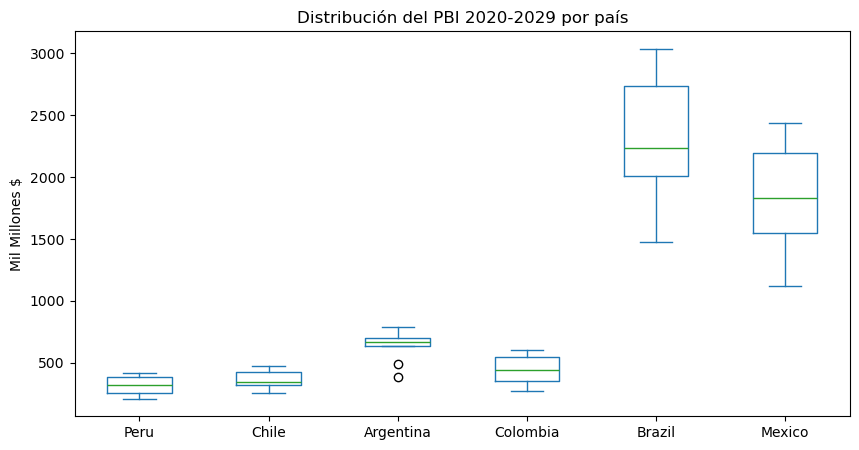

In [186]:
df_countries.plot(kind="box", figsize=(10, 5))
plt.title("Distribución del PBI 2020-2029 por país")
plt.ylabel("Mil Millones $")
plt.show()

In [187]:
# ¿Qué años fueron atípicos para Argentina?
for index, value in get_outliers(df_countries, "Argentina").items():
    print(index, "-->", value)

2020 --> 385.218
2021 --> 486.04


### 📝 Ejercicio 4 — Outliers del dataset iris

Usando la función `get_outliers` definida en clase y el dataset iris (`dataset/iris.csv`, columnas `sepal_length`, `sepal_width`, `petal_length`, `petal_width`, `class`):

1. Grafique el boxplot de la columna `sepal_width`.
2. Obtenga programáticamente sus valores atípicos con `get_outliers`.
3. Verifique que la cantidad de outliers impresos coincide con los puntos que se ven fuera de los bigotes del boxplot.

15 --> 4.4
32 --> 4.1
33 --> 4.2
60 --> 2.0


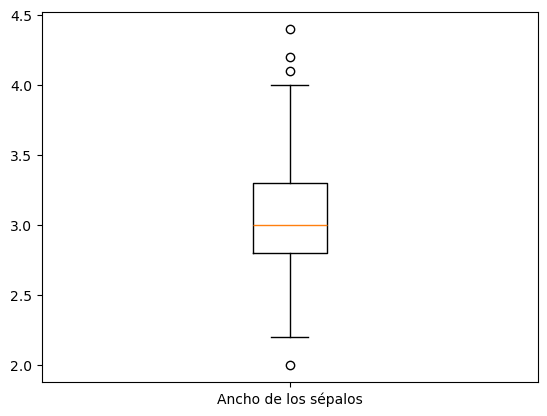

In [189]:
# Escriba su solución aquí

# Dataset iris 
titles = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]
data = pd.read_csv("dataset/research/iris.csv", names=titles)

# data.head()

plt.boxplot(data["sepal_width"], tick_labels=["Ancho de los sépalos"])
for index, value in get_outliers(data, "sepal_width").items():
  print(index, "-->", value)

## 3. Diagrama de dispersión (Scatter Plot)

### Teoría

Un **diagrama de dispersión** representa cada observación como un punto $(x_i, y_i)$. Es la herramienta visual para estudiar la **relación entre dos variables numéricas**, y la contraparte gráfica del coeficiente de correlación de Pearson que calculamos en la sesión 02:

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2}\;\sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

> Siempre conviene **graficar antes de confiar en $r$**: el coeficiente solo captura relaciones lineales — una relación en forma de U puede dar $r \approx 0$.

Parámetros útiles de `plt.scatter(x, y, ...)`: `color`/`c` (color fijo o un arreglo → mapa de color), `s` (tamaño de los puntos, fijo o un arreglo → burbujas), `alpha` (transparencia), `label` (para la leyenda).

### Laboratorio: dispersión a partir de listas

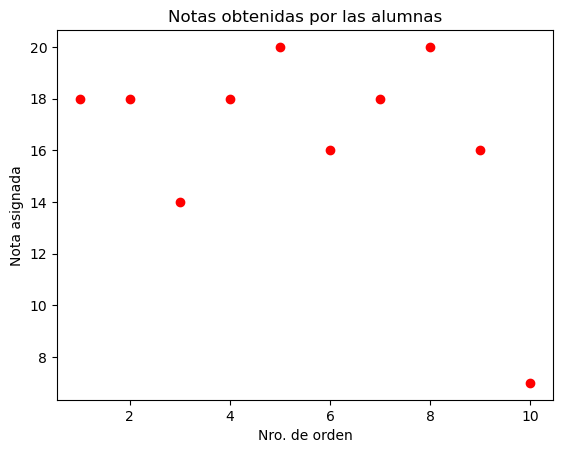

In [152]:
notas_alumnas    = [18, 18, 14, 18, 20, 16, 18, 20, 16, 7]
nro_orden_alumnas = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

plt.scatter(nro_orden_alumnas, notas_alumnas,
            color="r", label="Nota de Alumnas")

plt.title("Notas obtenidas por las alumnas")
plt.xlabel("Nro. de orden")
plt.ylabel("Nota asignada")
plt.savefig("output/scatter-01")
plt.show()

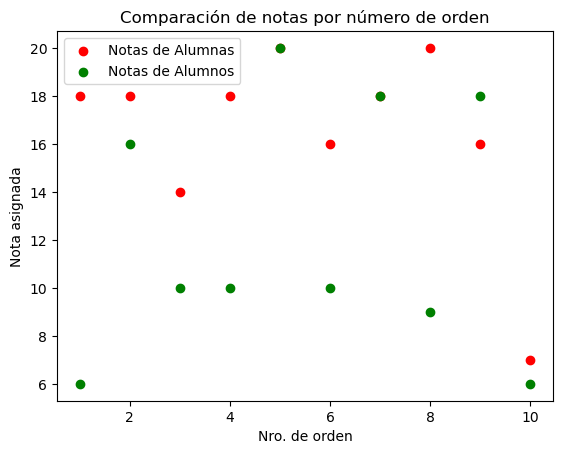

In [153]:
# Dos series en un mismo scatter, diferenciadas por color
notas_alumnos    = [6, 16, 10, 10, 20, 10, 18, 9, 18, 6]
nro_orden_alumnos = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

plt.scatter(nro_orden_alumnas, notas_alumnas, color="r", label="Notas de Alumnas")
plt.scatter(nro_orden_alumnos, notas_alumnos, color="g", label="Notas de Alumnos")

plt.title("Comparación de notas por número de orden")
plt.xlabel("Nro. de orden")
plt.ylabel("Nota asignada")
plt.legend()
plt.savefig("output/scatter-02")
plt.show()

### Dispersión a partir de un DataFrame

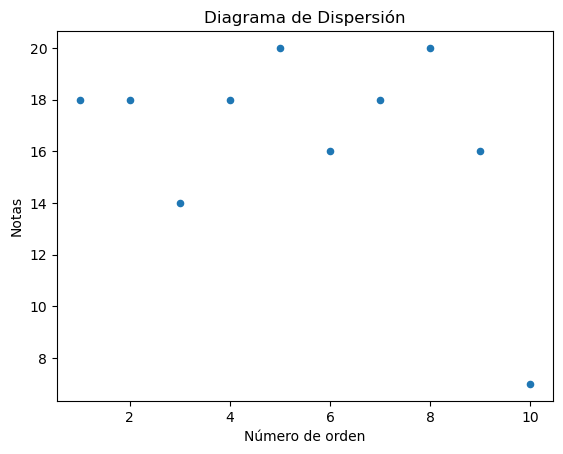

In [190]:
data = {"Nota de alumnas": [18, 18, 14, 18, 20, 16, 18, 20, 16, 7],
        "Número de orden": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}
df = pd.DataFrame(data)

df.plot(kind="scatter", x="Número de orden", y="Nota de alumnas")
plt.title("Diagrama de Dispersión")
plt.ylabel("Notas")
plt.savefig("output/scatter-03")
plt.show()

Para superponer dos scatter de pandas, el segundo `plot` recibe el eje del primero con el parámetro `ax`:

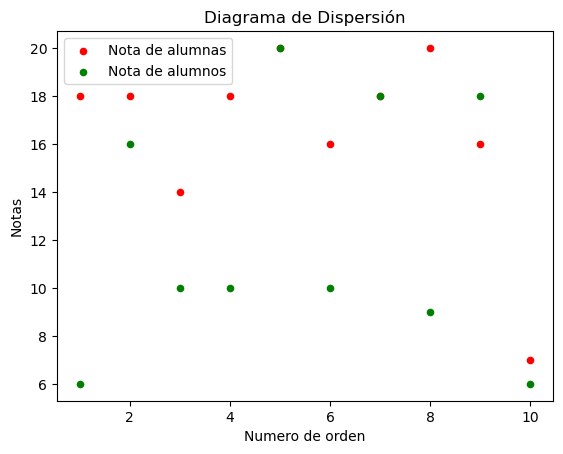

In [155]:
data = {"Nota de alumnas": [18, 18, 14, 18, 20, 16, 18, 20, 16, 7],
        "Nota de alumnos": [6, 16, 10, 10, 20, 10, 18, 9, 18, 6],
        "Numero de orden": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]}
df = pd.DataFrame(data)

ax0 = df.plot(kind="scatter", x="Numero de orden", y="Nota de alumnas",
              label="Nota de alumnas", color="r")

df.plot(kind="scatter", x="Numero de orden", y="Nota de alumnos",
        label="Nota de alumnos", color="g", ax=ax0)

ax0.set_title("Diagrama de Dispersión")
ax0.set_ylabel("Notas")
plt.savefig("output/scatter-04")
plt.show()

### Dispersión a partir de un archivo CSV

In [191]:
filename = "dataset/fmi/WEO_Data_Latinoamerica_2026.csv"
df = pd.read_csv(filename)
df.set_index("COUNTRY", inplace=True)

# Analiza un pais en un rango de años
range_year = [str(x) for x in range(2010, 2032)]
df_country = df.loc["Peru", range_year].to_frame()
df_country.reset_index(inplace=True)
df_country.columns = ["Año", "Peru"]     # nombres claros para los ejes
df_country.head()

,Año,Peru
0,2010,149.267
1,2011,170.773
2,2012,193.268
3,2013,201.568
4,2014,203.671


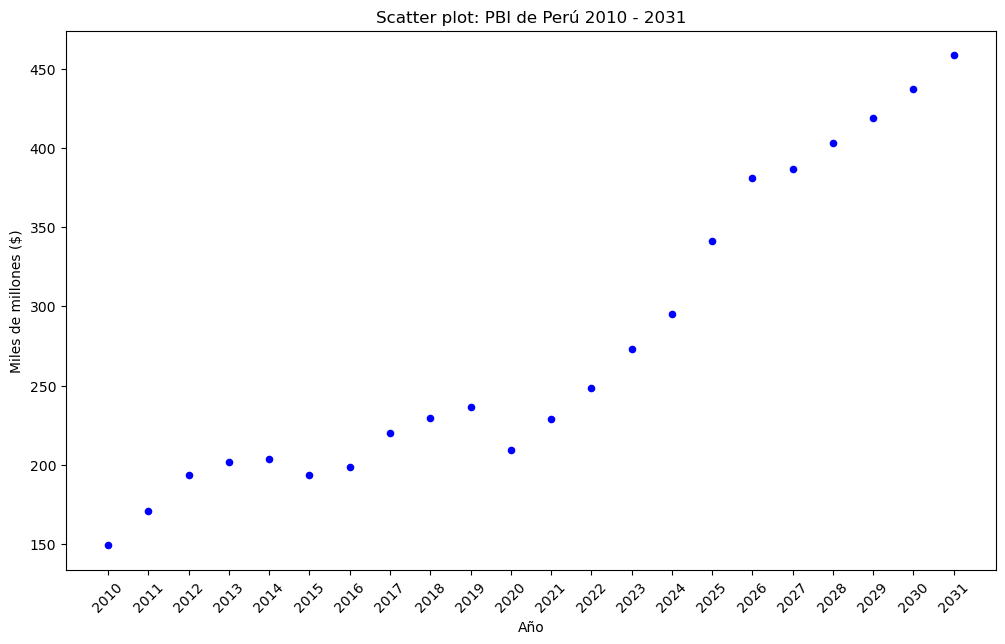

In [192]:
df_country.plot(kind="scatter", x="Año", y="Peru",
                figsize=(12, 7), color="blue")
plt.title("Scatter plot: PBI de Perú 2010 - 2031")
plt.xlabel("Año")
plt.ylabel("Miles de millones ($)")
plt.xticks(rotation=45)
plt.savefig("output/scatter-peru")
plt.show()

### Dimensiones adicionales: color y tamaño

El scatter puede codificar más variables: `c` con un arreglo numérico colorea los puntos (con `plt.colorbar()` como escala) y `s` con un arreglo controla el tamaño (gráfico de **burbujas**). Con el medallero: Oro vs Plata, tamaño según Bronce:

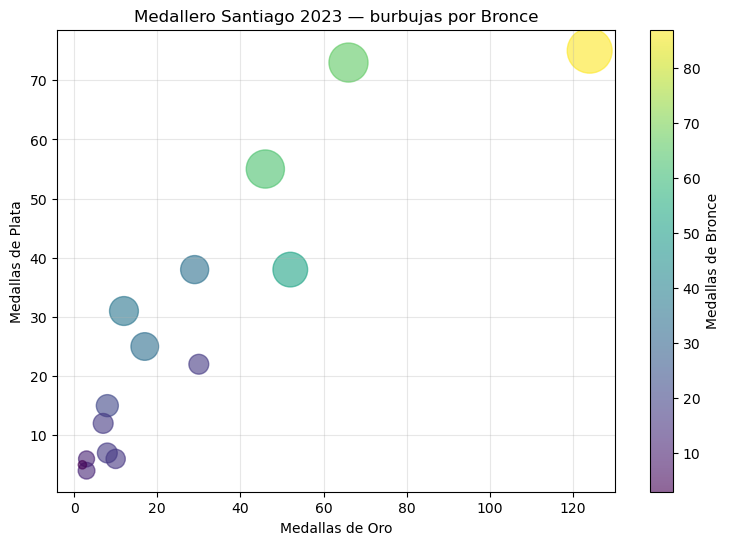

In [198]:
df_med = pd.read_csv("dataset/panamericanos/medallero_Panamericanos_Santiago2023.csv")
top15 = df_med.head(15)

plt.figure(figsize=(9, 6))
plt.scatter(top15["Oro"], top15["Plata"],
            s=top15["Bronce"] * 12,          # tamaño ∝ Bronce
            c=top15["Bronce"], cmap="viridis",
            alpha=0.6)
plt.colorbar(label="Medallas de Bronce")
plt.title("Medallero Santiago 2023 — burbujas por Bronce")
plt.xlabel("Medallas de Oro")
plt.ylabel("Medallas de Plata")
plt.grid(True, alpha=0.3)
plt.show()

### 📝 Ejercicio 5 — Dispersión del PBI de Argentina

Hacer un diagrama de dispersión del PBI de **Argentina** entre los años 2010 y 2031, usando la base de datos del FMI del 2026 (`WEO_Data_Latinoamerica_2026.csv`). Incluya título, etiquetas, rotación de los años en el eje x y guarde la figura.

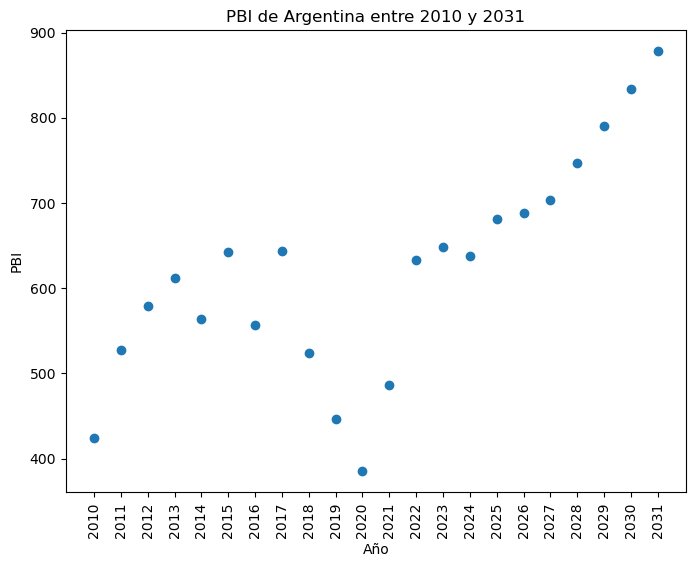

In [200]:
# Escriba su solución aquí
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("dataset/fmi/WEO_Data_Latinoamerica_2026.csv")


argentina = df[df["COUNTRY"] == "Argentina"]
anios = [str(año) for año in range(2010, 2032)]


plt.figure(figsize=(8, 6))


plt.scatter(anios, argentina[anios].values[0])


plt.title("PBI de Argentina entre 2010 y 2031")
plt.xlabel("Año")
plt.ylabel("PBI")


plt.xticks(rotation=90)
plt.savefig("pbi_argentina_2010_2031.png")
plt.show()

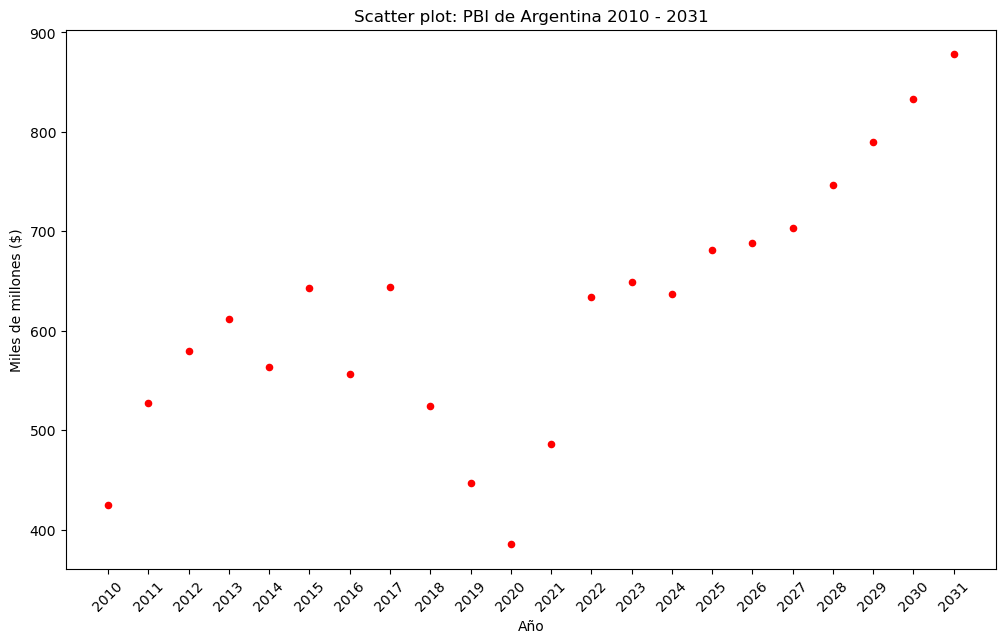

In [205]:
df = pd.read_csv("dataset/fmi/WEO_Data_Latinoamerica_2026.csv")

df.set_index("COUNTRY", inplace=True)
range_year = [str(x) for x in range(2010, 2032)]
df_country = df.loc["Argentina", range_year].to_frame()
df_country.reset_index(inplace=True)
df_country.columns = ["Año", "Argentina"]  
# df_country.head()


df_country.plot(kind="scatter", x="Año", y="Argentina",
        figsize=(12, 7), color="Red")
plt.title("Scatter plot: PBI de Argentina 2010 - 2031")
plt.xlabel("Año")
plt.ylabel("Miles de millones ($)")
plt.xticks(rotation=45)
plt.savefig("output/scatter-peru")
plt.show()

## 4. Seaborn

### Teoría

**Seaborn** es una librería construida **sobre matplotlib** que ofrece una interfaz de más alto nivel: funciones que reciben directamente un DataFrame y los nombres de las columnas (`x=`, `y=`, `data=`), calculan agregaciones automáticamente y aplican estilos más cuidados. Todo lo de matplotlib (`plt.title`, `plt.figure`...) sigue funcionando encima.

| Función | Qué hace |
|---|---|
| `sns.barplot` | Barras con el **promedio** (y su intervalo de confianza) de y por categoría |
| `sns.countplot` | Barras con el **conteo** de filas por categoría |
| `sns.boxplot` | Un boxplot de y **por cada categoría** de x |
| `sns.histplot` | Histograma, con opción de curva de densidad (`kde=True`) |

- https://seaborn.pydata.org/
- https://seaborn.pydata.org/api.html

### Laboratorio

In [210]:
import seaborn as sns

FILENAME = "dataset/panamericanos/medallero_Panamericanos_Lima2019.csv"
df = pd.read_csv(FILENAME)
df.head(10)

,Posicion,Pais,Oro,Plata,Bronce,Total,RankingTotal,Zona
0,1,Estados Unidos,120,88,85,293,1,America del Norte
1,2,Brasil,55,45,71,171,2,America del Sur
2,3,México,37,36,63,136,4,America del Norte
3,4,Canadá,35,64,53,152,3,America del Norte
4,5,Cuba,33,27,38,98,6,America del Centro
5,6,Argentina,32,35,34,101,5,America del Sur
6,7,Colombia,28,23,33,84,7,America del Sur
7,8,Chile,13,19,18,50,8,America del Sur
8,9,Perú,11,7,21,39,11,America del Sur
9,10,República Dominicana,10,13,17,40,10,America del Centro


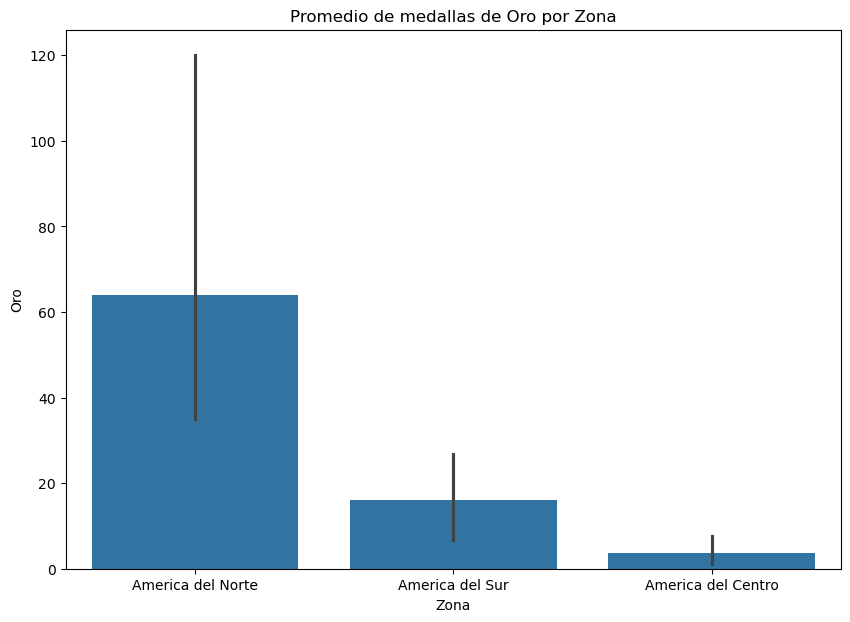

In [208]:
# barplot: promedio de Oro por zona (la línea vertical es el intervalo de confianza)
plt.figure(figsize=(10, 7))
sns.barplot(x="Zona", y="Oro", data=df)
plt.title("Promedio de medallas de Oro por Zona")
plt.show()

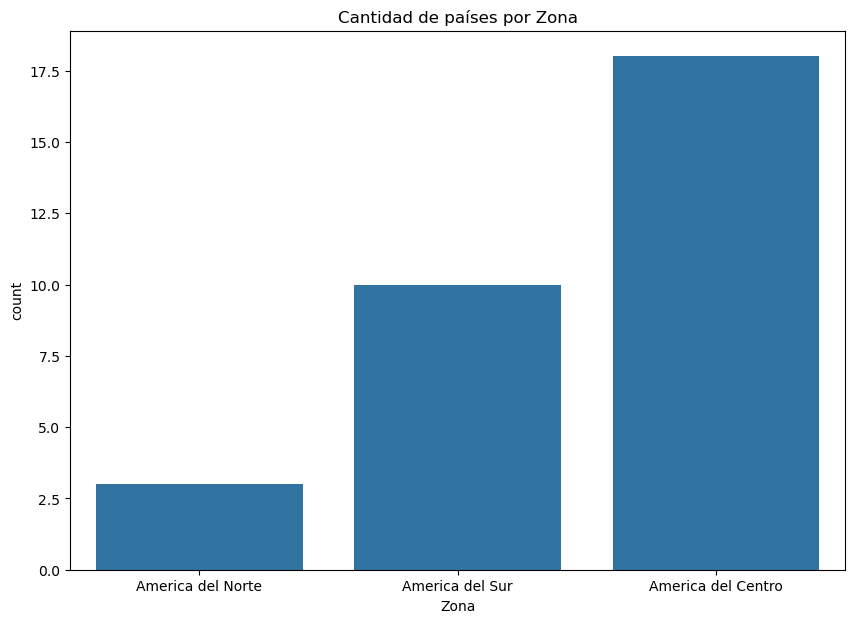

In [209]:
# countplot: cuántos países hay por zona
plt.figure(figsize=(10, 7))
sns.countplot(x="Zona", data=df)
plt.title("Cantidad de países por Zona")
plt.show()

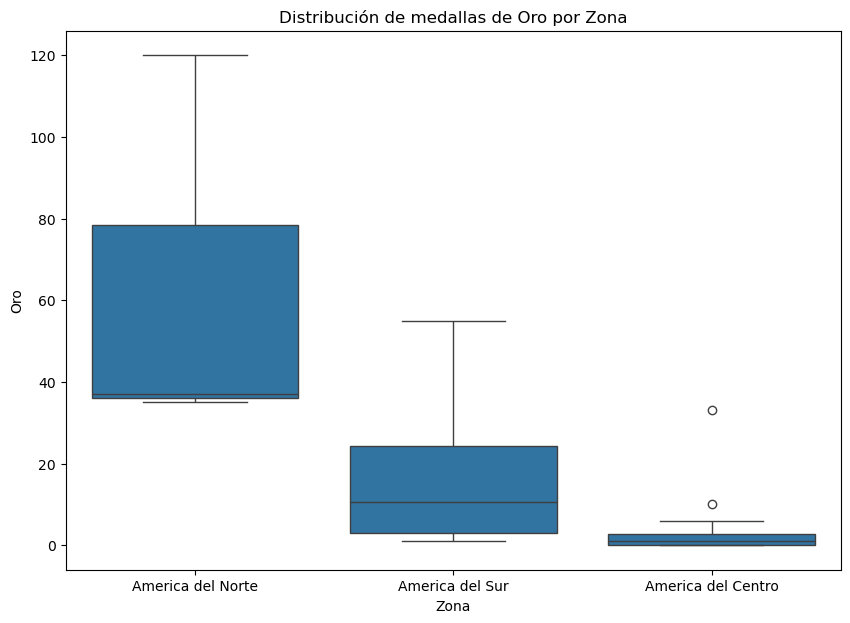

In [211]:
# boxplot por categoría: distribución del Oro en cada zona
plt.figure(figsize=(10, 7))
sns.boxplot(x="Zona", y="Oro", data=df)
plt.title("Distribución de medallas de Oro por Zona")
plt.show()

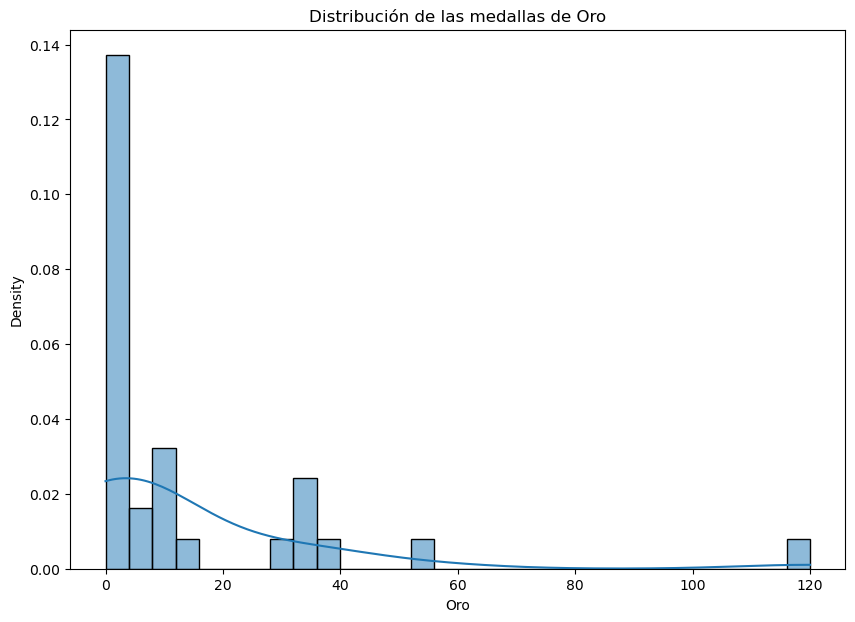

In [218]:
# histplot con curva de densidad
plt.figure(figsize=(10, 7))
sns.histplot(df["Oro"], bins=30, kde=True, stat="density")
plt.title("Distribución de las medallas de Oro")
plt.show()

In [219]:
# NOTA: cómo construir k intervalos equitativos entre dos valores
# (útil para pasar bordes exactos al parámetro bins)
bins = np.linspace(20, 140, 5 + 1)
print(bins)

[ 20.  44.  68.  92. 116. 140.]


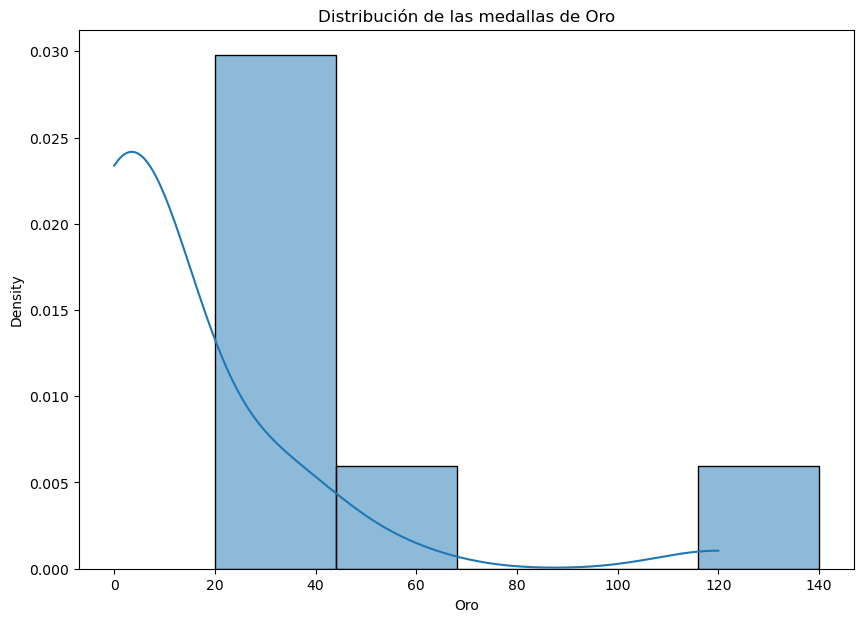

In [221]:
# histplot con curva de densidad
plt.figure(figsize=(10, 7))
sns.histplot(df["Oro"], bins=bins, kde=True, stat="density")
plt.title("Distribución de las medallas de Oro")
plt.show()

### 📝 Ejercicio 5 — Seaborn con el medallero

Con el medallero de Lima 2019:

1. Grafique con `sns.barplot` el promedio de medallas de **Plata** por `Zona`.
2. Grafique con `sns.boxplot` la distribución del **Total** de medallas (Oro + Plata + Bronce) por `Zona`.
3. Interprete: ¿qué zona domina el medallero y en cuál hay mayor variabilidad entre países?

In [166]:
# Escriba su solución aquí


## 5. Fuentes de datos en línea: APIs

### Teoría

Hasta ahora leímos datos de archivos locales. Una **API** (*Application Programming Interface*) web permite pedir datos actualizados directamente a una institución mediante una URL; la respuesta suele llegar en formato **JSON** (estructura de diccionarios y listas). En Python usamos la librería `requests`:

```
respuesta = requests.get(url).json()   # dict de Python
```

El trabajo consiste en explorar la estructura del JSON, extraer lo que interesa y convertirlo a un DataFrame para analizarlo y graficarlo como ya sabemos.

### Laboratorio: BCRP (tipo de cambio)

API del Banco Central de Reserva del Perú: series estadísticas en JSON. Dos detalles del formato del BCRP que hay que tratar antes de graficar:

1. Las fechas llegan con el mes abreviado **en español** (`Ene`, `Abr`, `Ago`, `Set`...), que `pd.to_datetime` no entiende — las traducimos antes de convertir.
2. Los días **sin cotización** (fines de semana y feriados) llegan con el valor `"n.d."` (*no disponible*) en lugar de un número. Si se lo pasamos a `float()` obtenemos `ValueError: could not convert string to float: 'n.d.'` — hay que **filtrarlos**. En este rango, el `01.May.26` (Día del Trabajo) es uno de esos días.

> 💡 Este es un caso típico de **limpieza de datos**: casi ninguna fuente real entrega la serie completa y numérica.

In [167]:
import requests

# URL de la API del BCRP: tipo de cambio del 01 al 16 de mayo de 2026
url = "https://estadisticas.bcrp.gob.pe/estadisticas/series/api/PD04640PD/json/2026-05-01/2026-05-16"

data = requests.get(url).json()

# OJO: el BCRP devuelve "n.d." (no disponible) en los días sin cotización
# —feriados y fines de semana, p.ej. el 01.May.26 (Día del Trabajo)—.
# Si intentamos float("n.d.") obtenemos ValueError, así que los descartamos.
info = [{"fecha": item["name"], "tipo_cambio": float(item["values"][0])}
        for item in data["periods"]
        if item["values"][0] != "n.d."]

df = pd.DataFrame(info)

# Traducción de los meses ES -> EN para que to_datetime los entienda
meses = {"Ene": "Jan", "Feb": "Feb", "Mar": "Mar", "Abr": "Apr",
         "May": "May", "Jun": "Jun", "Jul": "Jul", "Ago": "Aug",
         "Set": "Sep", "Sep": "Sep", "Oct": "Oct", "Nov": "Nov", "Dic": "Dec"}

for es, en in meses.items():
    df["fecha"] = df["fecha"].str.replace(f".{es}.", f".{en}.", regex=False)

df["fecha"] = pd.to_datetime(df["fecha"], format="%d.%b.%y")
df.head()

,fecha,tipo_cambio
0,2026-05-04,3.522
1,2026-05-05,3.498
2,2026-05-06,3.470
3,2026-05-07,3.461
4,2026-05-08,3.450


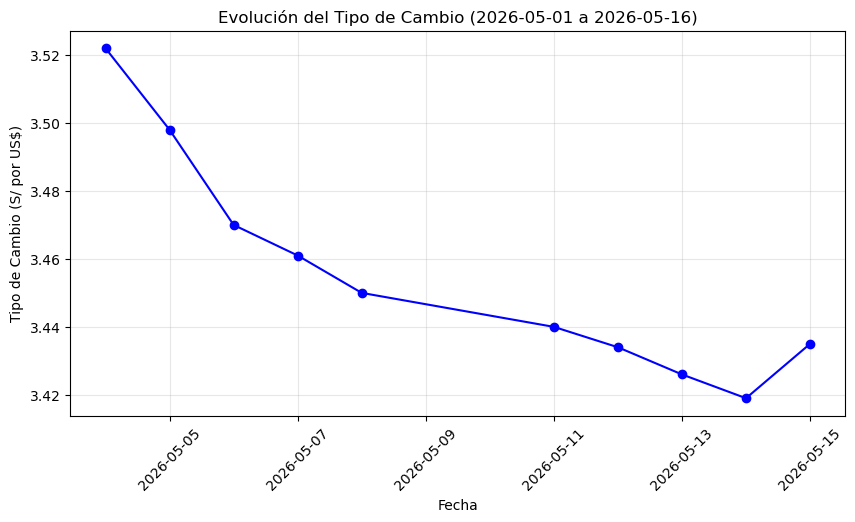

In [168]:
# Graficamos la serie temporal del tipo de cambio
plt.figure(figsize=(10, 5))
plt.plot(df["fecha"], df["tipo_cambio"], marker="o", linestyle="-", color="blue")
plt.title("Evolución del Tipo de Cambio (2026-05-01 a 2026-05-16)")
plt.xlabel("Fecha")
plt.ylabel("Tipo de Cambio (S/ por US$)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.savefig("output/tipo_cambio_bcrp.png")
plt.show()

### Laboratorio: FMI (DataMapper)

La API del FMI expone indicadores por país. Encapsulamos la consulta en una función reutilizable (`NGDPD` = PBI en miles de millones de US$; el país se indica con su código ISO de 3 letras):

In [169]:
def get_imf_data(indicador, pais, años=None):
    """Consulta el DataMapper del FMI y devuelve un dict {año: valor}."""
    url = f"https://www.imf.org/external/datamapper/api/v2/{indicador}/{pais}"
    data = requests.get(url).json()

    serie = data["values"][indicador][pais]

    if años:
        años_str = [str(a) for a in años]
        serie = {a: v for a, v in serie.items() if a in años_str}

    return serie

# Uso: PBI de Perú
pib = get_imf_data("NGDPD", "PER", años=range(2019, 2033))

for año, valor in sorted(pib.items()):
    print(f"{año}: US$ {valor:,.2f} mil millones")

2019: US$ 236.26 mil millones
2020: US$ 209.06 mil millones
2021: US$ 228.70 mil millones
2022: US$ 248.18 mil millones
2023: US$ 272.75 mil millones
2024: US$ 295.22 mil millones
2025: US$ 341.02 mil millones
2026: US$ 380.90 mil millones
2027: US$ 386.38 mil millones
2028: US$ 402.72 mil millones
2029: US$ 418.91 mil millones
2030: US$ 437.10 mil millones
2031: US$ 458.41 mil millones


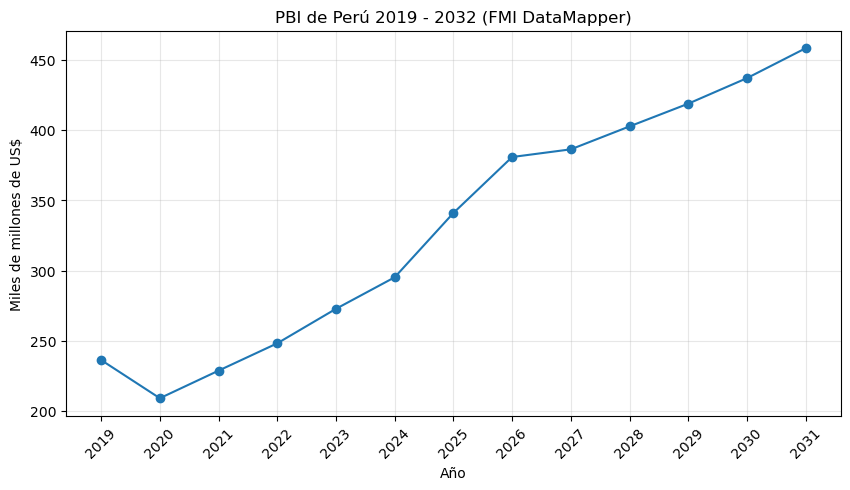

In [170]:
# Y como ya es un dict, graficarlo es directo
serie_peru = pd.Series(pib).sort_index()

plt.figure(figsize=(10, 5))
plt.plot(serie_peru.index, serie_peru.values, marker="o")
plt.title("PBI de Perú 2019 - 2032 (FMI DataMapper)")
plt.xlabel("Año")
plt.ylabel("Miles de millones de US$")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

### 📝 Ejercicio 6 — Consumo de una API: PBI desde el FMI

Usando la función `get_imf_data` vista en clase:

1. Obtenga el PBI de **Chile** (`"CHL"`) entre 2015 y 2030 (indicador `"NGDPD"`).
2. Grafique la serie con línea y marcadores, rotando los años del eje x.
3. Agregue título y etiquetas apropiadas.

In [171]:
# Escriba su solución aquí


## Resumen de la sesión

| Gráfico / herramienta | Pregunta que responde | Función |
|---|---|---|
| Circular | ¿Qué parte del todo representa cada categoría? | `plt.pie` |
| Boxplot | ¿Cómo se distribuye una variable y hay outliers? | `plt.boxplot` / `.plot(kind="box")` |
| Dispersión | ¿Cómo se relacionan dos variables numéricas? | `plt.scatter` |
| Seaborn | Lo mismo, agrupado por categorías y con menos código | `sns.barplot`, `sns.boxplot`, ... |
| APIs | ¿Cómo obtengo datos actualizados sin archivos locales? | `requests.get(url).json()` |